# End-to-End Supervised Learning Workflow: HDB Resale Price Prediction with CatBoost

**Goal**: Build a supervised regression workflow to predict `resale_price` from the training dataset using `CatBoostRegressor`.

**Scenario**

The dataset contains flat attributes, transaction timing, address/location signals, nearby amenities, schools, and transport features. The target variable is `resale_price`, so this is a supervised regression problem evaluated with RMSE.

**Workflow**

1. Load the sample submission, test data, and training data.
2. Define sklearn-compatible feature transformers for transaction timing, lease/age/storey features, flat-type ordinal encoding, distance/accessibility features, categorical combinations, geohash spatial indexing, and HDBSCAN geo-cluster features.
3. Convert each latitude/longitude pair (flat, MRT, bus stop, primary school, secondary school) into geohash buckets at precisions 5, 6, 7 (coarse → fine neighborhood labels). S2 retired as redundant with geohash.
4. Split labeled training data into features (`X`) and target (`Y`).
5. Define preprocessing groups: dropped identifiers/raw coordinate columns, regular categorical columns, spatial-index categorical columns. Numerics passed through raw — CatBoost is tree-based and does not need scaling. Old scaler code retained, commented out, at the end of the notebook for reference.
6. Build a reusable pipeline that creates engineered features, drops unused/raw coordinate columns, imputes categorical missing values, and passes both numerics and categoricals to CatBoost (categoricals via `cat_features` for native handling).
7. Create a held-out test split (`X_test`) AND a tuning validation split (`X_val`) carved from `X_train`. `X_test` is touched exactly once at the end of tuning for an honest generalization estimate. `X_val` is used as `eval_set` during hyperparameter search for early stopping. This avoids leaking the held-out test set.
8. Step A — fit a baseline CatBoost on `X_train`, evaluate on `X_test`.
9. Step B — 10-fold CV on `X_train` as a stability benchmark (informational only; does not select a model).
10. Step C — randomized hyperparameter search over `X_tr` with early stopping on `X_val`; capture best params and `best_iteration_`. Refit on full `X_train` with best params, evaluate once on `X_test`.
11. Step D — re-derive iteration count for full-data fit (`final_iter ≈ 1.1 × best_iter`), refit on all labeled data (`X_train ∪ X_test`), predict the Kaggle test data, save the model, and write the submission CSV.


## 1. Imports and Data Loading

First, import the libraries used throughout the workflow and load the training dataset. The `id` column is used as the dataframe index.


In [1]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor, Pool
import geohash2
import hdbscan
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, ParameterSampler, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

pd.set_option('display.max_columns', 120)


In [2]:
# load submission format
df_sub = pd.read_csv('data/sample_sub_reg.csv')

df_sub.shape
df_sub.head()


,Id,Predicted
0,114982,500000
1,95653,500000
2,40303,500000
3,109506,500000
4,100149,500000


In [3]:
# load test dataset
df_test = pd.read_csv('data/test.csv')

df_test.shape
df_test.head()

/var/folders/44/bfmr660d6dz4w35pkrfps0700000gn/T/ipykernel_49576/3630737951.py:2: DtypeWarning: Columns (0: postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('data/test.csv')


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,114982,2012-11,YISHUN,4 ROOM,173,YISHUN AVE 7,07 TO 09,84.0,Simplified,1987,2012,11,8,7,9,8,4 ROOM Simplified,"173, YISHUN AVE 7",904.176,34,12,1986,Y,Y,N,N,N,132,0,0,0,92,40,0,0,0,0,0,0,0,760173,1.437066,103.831121,Yishun,877.431572,NaN,2.0,4.0,687.576779,NaN,1.0,1.0,56,123,686.660434,Canberra,0,0,1.443077,103.829703,75.683952,Blk 174,1.437558,103.831591,426.467910,Ahmad Ibrahim Primary School,92,0,1.433681,103.832924,156.322353,Ahmad Ibrahim Secondary School,218,0,1.436235,103.829987
1,95653,2019-08,JURONG WEST,5 ROOM,986C,JURONG WEST ST 93,04 TO 06,112.0,Premium Apartment,2008,2019,8,5,4,6,5,5 ROOM Premium Apartment,"986C, JURONG WEST ST 93",1205.568,13,14,2002,Y,N,N,N,N,53,0,0,0,28,25,0,0,0,0,0,0,0,643986,1.336957,103.695668,Jurong West,534.037705,NaN,1.0,3.0,2122.346226,NaN,NaN,NaN,72,94,169.478175,Pioneer,0,0,1.337343,103.697143,88.993058,Blk 653B,1.336491,103.696319,439.756851,Jurong West Primary School,45,0,1.339244,103.698896,739.371688,Jurong West Secondary School,199,0,1.335256,103.702098
2,40303,2013-10,ANG MO KIO,3 ROOM,534,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,1980,2013,10,8,7,9,8,3 ROOM New Generation,"534, ANG MO KIO AVE 10",731.952,41,12,1979,Y,N,N,N,N,218,0,0,191,22,1,1,0,0,0,0,3,0,560534,1.374058,103.854168,Ang Mo Kio,817.050453,NaN,2.0,3.0,152.287621,1.0,3.0,11.0,50,100,694.220448,Ang Mo Kio,1,0,1.369465,103.849939,86.303575,Blk 532,1.374255,103.854919,355.882207,Jing Shan Primary School,36,0,1.371893,103.851811,305.071191,Anderson Secondary School,245,0,1.374242,103.851430
3,109506,2017-10,WOODLANDS,4 ROOM,29,MARSILING DR,01 TO 03,97.0,New Generation,1979,2017,10,2,1,3,2,4 ROOM New Generation,"29, MARSILING DR",1044.108,42,14,1976,Y,N,N,N,N,104,0,0,0,104,0,0,0,0,0,0,0,0,731029,1.442748,103.772922,Woodlands,1272.737194,NaN,NaN,3.0,501.892158,NaN,1.0,2.0,52,112,1117.203587,Marsiling,0,0,1.432757,103.773982,108.459039,Blk 32,1.443650,103.773295,929.744711,Marsiling Primary School,54,0,1.434423,103.773698,433.454591,Woodlands Secondary School,188,0,1.439183,103.774499
4,100149,2016-08,BUKIT BATOK,4 ROOM,170,BT BATOK WEST AVE 8,16 TO 18,103.0,Model A,1985,2016,8,17,16,18,17,4 ROOM Model A,"170, BT BATOK WEST AVE 8",1108.692,36,25,1985,Y,N,N,N,N,144,0,0,0,48,96,0,0,0,0,0,0,0,650170,1.346556,103.740101,Bukit Batok,1070.963675,NaN,NaN,5.0,437.593564,1.0,2.0,2.0,60,87,987.976010,Chinese Garden,0,0,1.342441,103.732225,113.645431,Blk 169,1.346899,103.741064,309.926934,Princess Elizabeth Primary School,40,0,1.349195,103.741000,217.295361,Bukit Batok Secondary School,223,0,1.348351,103.740873


In [4]:
# Load the training dataset.
df = pd.read_csv('data/train.csv')

df.shape

/var/folders/44/bfmr660d6dz4w35pkrfps0700000gn/T/ipykernel_49576/3207937961.py:2: DtypeWarning: Columns (0: postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train.csv')


(150634, 77)

## 2. Feature Engineering Inside the Pipeline

Define feature engineering as a sklearn transformer so the model can receive raw data at both training time and prediction time. The transformer learns the first transaction month during `fit`, then creates transaction timing, lease, age, flat-type ordinal, and storey-ratio features during every `transform`.


In [5]:
class TransactionDateFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, transaction_col='Tranc_YearMonth'):
        self.transaction_col = transaction_col
        self.flat_type_ordinal_map = {
            '1 ROOM': 1,
            '2 ROOM': 2,
            '3 ROOM': 3,
            '4 ROOM': 4,
            '5 ROOM': 5,
            'EXECUTIVE': 6,
            'MULTI-GENERATION': 7,
            'MULTI GENERATION': 7,
        }
        self.engineered_features = [
            'days_from_first_transaction',
            'month_sin',
            'month_cos',
            'transaction_quarter',
            'remaining_lease',
            'property_age_at_sale',
            'is_new_flat',
            'is_old_flat',
            'flat_type_ordinal',
            'storey_mid_ratio',
            'log_mrt_dist',
            'log_mall_dist',
            'log_hawker_dist',
            'log_bus_dist',
            'log_pri_sch_dist',
            'log_sec_sch_dist',
            'accessibility_score',
            'mrt_walkable',
            'bus_walkable',
            'mall_walkable',
            'hawker_walkable',
            'pri_school_walkable',
            'sec_school_walkable',
            'integrated_transport_access',
            'town_full_flat_type',
            'block_street_name',
            'street_name_pri_sch_name',
            'street_name_sec_sch_name',
        ]

    def fit(self, X, y=None):
        transaction_dates = pd.to_datetime(X[self.transaction_col], errors='coerce')
        self.first_transaction_date_ = transaction_dates.min()
        return self

    def transform(self, X):
        X = X.copy()
        transaction_dates = pd.to_datetime(X[self.transaction_col], errors='coerce')
        trans_year = pd.to_numeric(X['Tranc_Year'], errors='coerce')
        trans_month = pd.to_numeric(X['Tranc_Month'], errors='coerce')
        lease_commence_date = pd.to_numeric(X['lease_commence_date'], errors='coerce')
        year_completed = pd.to_numeric(X['year_completed'], errors='coerce')
        mid_storey = pd.to_numeric(X['mid_storey'], errors='coerce')
        max_floor_lvl = pd.to_numeric(X['max_floor_lvl'], errors='coerce')
        mrt_distance = pd.to_numeric(X['mrt_nearest_distance'], errors='coerce')
        mall_distance = pd.to_numeric(X['Mall_Nearest_Distance'], errors='coerce')
        hawker_distance = pd.to_numeric(X['Hawker_Nearest_Distance'], errors='coerce')
        bus_distance = pd.to_numeric(X['bus_stop_nearest_distance'], errors='coerce')
        pri_sch_distance = pd.to_numeric(X['pri_sch_nearest_distance'], errors='coerce')
        sec_sch_distance = pd.to_numeric(X['sec_sch_nearest_dist'], errors='coerce')

        X['days_from_first_transaction'] = (
            transaction_dates - self.first_transaction_date_
        ).dt.days

        X['month_sin'] = np.sin(2 * np.pi * trans_month / 12)
        X['month_cos'] = np.cos(2 * np.pi * trans_month / 12)
        X['transaction_quarter'] = np.ceil(trans_month / 3)
        X['remaining_lease'] = 99 - (trans_year - lease_commence_date)
        X['property_age_at_sale'] = trans_year - year_completed
        X['is_new_flat'] = (X['property_age_at_sale'] <= 6).astype(int)
        X['is_old_flat'] = (X['remaining_lease'] <= 60).astype(int)
        X['flat_type_ordinal'] = (
            X['flat_type']
            .astype('string')
            .str.upper()
            .map(self.flat_type_ordinal_map)
        )
        X['storey_mid_ratio'] = mid_storey / max_floor_lvl.replace(0, np.nan)

        X['log_mrt_dist'] = np.log1p(mrt_distance)
        X['log_mall_dist'] = np.log1p(mall_distance)
        X['log_hawker_dist'] = np.log1p(hawker_distance)
        X['log_bus_dist'] = np.log1p(bus_distance)
        X['log_pri_sch_dist'] = np.log1p(pri_sch_distance)
        X['log_sec_sch_dist'] = np.log1p(sec_sch_distance)

        X['accessibility_score'] = (
            1 / (1 + mrt_distance)
            + 1 / (1 + mall_distance)
            + 1 / (1 + hawker_distance)
            + 1 / (1 + bus_distance)
        ) / 4

        X['mrt_walkable'] = (mrt_distance <= 500).astype(int)
        X['bus_walkable'] = (bus_distance <= 500).astype(int)
        X['mall_walkable'] = (mall_distance <= 500).astype(int)
        X['hawker_walkable'] = (hawker_distance <= 500).astype(int)
        X['pri_school_walkable'] = (pri_sch_distance <= 500).astype(int)
        X['sec_school_walkable'] = (sec_sch_distance <= 500).astype(int)
        X['integrated_transport_access'] = (
            X['bus_interchange'].astype(bool) & X['mrt_interchange'].astype(bool)
        ).astype(int)

        X['town_full_flat_type'] = X['town'].astype('string') + '_' + X['full_flat_type'].astype('string')
        X['block_street_name'] = X['block'].astype('string') + '_' + X['street_name'].astype('string')
        X['street_name_pri_sch_name'] = X['street_name'].astype('string') + '_' + X['pri_sch_name'].astype('string')
        X['street_name_sec_sch_name'] = X['street_name'].astype('string') + '_' + X['sec_sch_name'].astype('string')

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array(list(input_features) + self.engineered_features, dtype=object)



class SpatialIndexFeatures(BaseEstimator, TransformerMixin):
    """
    Geohash spatial buckets at multiple precisions for each lat/lon pair.
    p5 ~ 5km (town), p6 ~ 1.2km (neighborhood), p7 ~ 150m (block cluster).
    p8 dropped: too fine, overlaps with block-level features and adds noisy
    target stats. S2 dropped: redundant with geohash for SG (small, near-equator).
    """
    def __init__(
        self,
        coordinate_pairs=None,
        geohash_precisions=(5, 6, 7),
    ):
        self.coordinate_pairs = coordinate_pairs or {
            'flat': ('Latitude', 'Longitude'),
            'mrt': ('mrt_latitude', 'mrt_longitude'),
            'bus_stop': ('bus_stop_latitude', 'bus_stop_longitude'),
            'pri_sch': ('pri_sch_latitude', 'pri_sch_longitude'),
            'sec_sch': ('sec_sch_latitude', 'sec_sch_longitude'),
        }
        self.geohash_precisions = tuple(geohash_precisions)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for location_name, (latitude_col, longitude_col) in self.coordinate_pairs.items():
            latitudes = pd.to_numeric(X[latitude_col], errors='coerce')
            longitudes = pd.to_numeric(X[longitude_col], errors='coerce')
            valid_coordinates = latitudes.notna() & longitudes.notna()

            for precision in self.geohash_precisions:
                feature_name = f'{location_name}_geohash_p{precision}'
                X[feature_name] = 'missing'
                X.loc[valid_coordinates, feature_name] = [
                    geohash2.encode(lat, lon, precision=precision)
                    for lat, lon in zip(
                        latitudes.loc[valid_coordinates],
                        longitudes.loc[valid_coordinates],
                    )
                ]

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        spatial_features = []
        for location_name in self.coordinate_pairs:
            spatial_features.extend([
                f'{location_name}_geohash_p{precision}' for precision in self.geohash_precisions
            ])
        return np.array(list(input_features) + spatial_features, dtype=object)


class GeoClusterFeatures(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        latitude_col='Latitude',
        longitude_col='Longitude',
        min_cluster_size=80,
        min_samples=20,
    ):
        self.latitude_col = latitude_col
        self.longitude_col = longitude_col
        self.min_cluster_size = min_cluster_size
        self.min_samples = min_samples
        self.engineered_features = ['geo_cluster', 'geo_cluster_prob', 'geo_noise_flag']

    def fit(self, X, y=None):
        coordinates = self._coordinate_frame(X)
        self.fallback_coordinates_ = coordinates.median()
        coordinates = coordinates.fillna(self.fallback_coordinates_)

        self.clusterer_ = hdbscan.HDBSCAN(
            min_cluster_size=self.min_cluster_size,
            min_samples=self.min_samples,
            prediction_data=True,
        )
        self.clusterer_.fit(coordinates)
        return self

    def transform(self, X):
        X = X.copy()
        coordinates = self._coordinate_frame(X).fillna(self.fallback_coordinates_)

        labels, probabilities = hdbscan.approximate_predict(self.clusterer_, coordinates)
        X['geo_cluster'] = pd.Series(labels, index=X.index).astype('string')
        X['geo_cluster_prob'] = probabilities
        X['geo_noise_flag'] = (labels == -1).astype(int)
        return X

    def _coordinate_frame(self, X):
        return pd.DataFrame({
            self.latitude_col: pd.to_numeric(X[self.latitude_col], errors='coerce'),
            self.longitude_col: pd.to_numeric(X[self.longitude_col], errors='coerce'),
        }, index=X.index)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array(list(input_features) + self.engineered_features, dtype=object)


class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns, errors='ignore')

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array([col for col in input_features if col not in self.columns], dtype=object)


## 3. Feature Selection and Target Split

Rows with missing values are removed instead of imputed. Then `resale_price` is separated as the target variable.


In [6]:
df_ml = df.copy()

# ---------------------------------------------------------------------------
# Sort by transaction date (Tranc_YearMonth) so that any downstream consumer
# of df_ml sees rows in chronological order. The train/test split below uses
# shuffle=True (random holdout), but X_train is re-sorted before time-series
# CV in Section 9 — sorting here keeps df_ml itself coherent for inspection.
# ---------------------------------------------------------------------------
df_ml = df_ml.sort_values('Tranc_YearMonth', kind='stable').reset_index(drop=True)
print(f'>>> df_ml sorted by Tranc_YearMonth: '
      f'{df_ml["Tranc_YearMonth"].min()} -> {df_ml["Tranc_YearMonth"].max()}')

Y = df_ml['resale_price']
X = df_ml.drop(columns=['resale_price'])

print(f'Original rows: {df.shape[0]}')
print(f'Rows kept for modeling: {df_ml.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'Target: {Y.name}')

X.sample(2)


>>> df_ml sorted by Tranc_YearMonth: 2012-03 -> 2021-04
Original rows: 150634
Rows kept for modeling: 150634
Features: 76
Target: resale_price


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
92457,176098,2018-04,SERANGOON,EXECUTIVE,519,SERANGOON NTH AVE 4,04 TO 06,150.0,Maisonette,1992,2018,4,5,4,6,5,EXECUTIVE Maisonette,"519, SERANGOON NTH AVE 4",1614.600,29,9,1991,Y,N,N,N,N,72,0,0,0,0,0,72,0,0,0,0,0,0,550519,1.371992,103.874590,Serangoon,676.507784,NaN,1.0,6.0,985.400877,NaN,1.0,4.0,40,0,1741.575050,Kovan,0,0,1.359703,103.884303,132.624622,Opp Blk 506A,1.372976,103.875264,103.330491,Rosyth School,20,0,1.372916,103.874693,347.476704,Bowen Secondary School,224,0,1.370751,103.877459
114889,158670,2019-07,TAMPINES,5 ROOM,522C,TAMPINES CTRL 7,16 TO 18,113.0,Improved,2015,2019,7,17,16,18,17,5 ROOM Improved,"522C, TAMPINES CTRL 7",1216.332,6,17,2014,Y,N,N,N,N,96,0,0,0,32,64,0,0,0,0,0,0,0,523522,1.358005,103.939416,Tampines,565.166791,NaN,5.0,6.0,562.643359,NaN,1.0,2.0,42,0,802.711361,Tampines,1,1,1.353539,103.945090,132.506146,BLK 519A,1.357529,103.940509,451.817220,Poi Ching School,70,0,1.358087,103.935352,845.265361,Junyuan Secondary School,188,0,1.353341,103.933411


## 4. Building the Preprocessing Groups

Two groups only:

1. **Dropped columns** — raw IDs, raw lat/lon (replaced by geohash buckets), and redundant raw columns.
2. **Categorical columns** — original string columns + engineered cross-features + geohash spatial buckets + HDBSCAN cluster label. All passed to CatBoost via `cat_features` for native handling.

Numerics are passed through raw — CatBoost is tree-based and is invariant to monotonic transforms, so scaling is unnecessary. The old standard/minmax scaler code is preserved at the bottom of the notebook (commented out) for reference.


In [7]:
# Dropped columns: raw IDs, raw coordinates (replaced by geohash), redundant raw cols.
raw_coordinate_cols = [
    'Latitude', 'Longitude',
    'mrt_latitude', 'mrt_longitude',
    'bus_stop_latitude', 'bus_stop_longitude',
    'pri_sch_latitude', 'pri_sch_longitude',
    'sec_sch_latitude', 'sec_sch_longitude',
]
drop_cols = [
    'id', 'postal', 'street_name', 'block', 'Tranc_YearMonth',
    'floor_area_sqft', 'address', 'storey_range', 'residential',
] + raw_coordinate_cols
model_input_cols = [col for col in X.columns if col not in drop_cols]

# Geohash buckets are categorical area labels (not ordered numerics).
spatial_index_cols = SpatialIndexFeatures().get_feature_names_out([]).tolist()

engineered_categorical_cols = [
    'town_full_flat_type',
    'block_street_name',
    'street_name_pri_sch_name',
    'street_name_sec_sch_name',
    'geo_cluster',
]

categorical_cols = (
    X[model_input_cols].select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    + spatial_index_cols
    + engineered_categorical_cols
)

print(f'Dropped columns ({len(drop_cols)}):')
print(drop_cols)
print()
print(f'Categorical columns ({len(categorical_cols)}):')
print(categorical_cols)


Dropped columns (19):
['id', 'postal', 'street_name', 'block', 'Tranc_YearMonth', 'floor_area_sqft', 'address', 'storey_range', 'residential', 'Latitude', 'Longitude', 'mrt_latitude', 'mrt_longitude', 'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_latitude', 'sec_sch_longitude']

Categorical columns (33):
['town', 'flat_type', 'flat_model', 'full_flat_type', 'commercial', 'market_hawker', 'multistorey_carpark', 'precinct_pavilion', 'planning_area', 'mrt_name', 'bus_stop_name', 'pri_sch_name', 'sec_sch_name', 'flat_geohash_p5', 'flat_geohash_p6', 'flat_geohash_p7', 'mrt_geohash_p5', 'mrt_geohash_p6', 'mrt_geohash_p7', 'bus_stop_geohash_p5', 'bus_stop_geohash_p6', 'bus_stop_geohash_p7', 'pri_sch_geohash_p5', 'pri_sch_geohash_p6', 'pri_sch_geohash_p7', 'sec_sch_geohash_p5', 'sec_sch_geohash_p6', 'sec_sch_geohash_p7', 'town_full_flat_type', 'block_street_name', 'street_name_pri_sch_name', 'street_name_sec_sch_name', 'geo_cluster']


In [8]:
# Sanity check: the engineered categorical columns + spatial buckets are
# created INSIDE the pipeline (after TransactionDateFeatures, SpatialIndexFeatures,
# GeoClusterFeatures run). The ColumnTransformer matches them by name at
# transform time, so they don't need to exist in raw X yet.
#
# All other columns (numerics + engineered numerics) are passed through to
# CatBoost without scaling.
print(f'Spatial index columns ({len(spatial_index_cols)}):')
print(spatial_index_cols)


Spatial index columns (15):
['flat_geohash_p5', 'flat_geohash_p6', 'flat_geohash_p7', 'mrt_geohash_p5', 'mrt_geohash_p6', 'mrt_geohash_p7', 'bus_stop_geohash_p5', 'bus_stop_geohash_p6', 'bus_stop_geohash_p7', 'pri_sch_geohash_p5', 'pri_sch_geohash_p6', 'pri_sch_geohash_p7', 'sec_sch_geohash_p5', 'sec_sch_geohash_p6', 'sec_sch_geohash_p7']


## 5. Building the Preprocessing Pipeline

The pipeline runs feature engineering, drops unused/raw columns, imputes categorical missing values to `'missing'`, and passes everything to CatBoost. Numerics flow through unchanged because CatBoost does not need scaling. CatBoost receives the categorical column indices via `cat_features` and handles them natively (target statistics + one-hot for low-cardinality columns controlled by `one_hot_max_size`).

The `make_regression_pipeline` factory is reused for the baseline, the cross-validation benchmark, the hyperparameter search candidates, and the final model.


In [9]:
# Categoricals: original strings + geohash buckets + engineered cross-features + geo cluster.
# Imputed to 'missing' string; CatBoost handles them natively via cat_features.
non_geo_categorical_cols = [col for col in categorical_cols if col not in spatial_index_cols]
catboost_categorical_cols = non_geo_categorical_cols + spatial_index_cols

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
])

# ColumnTransformer puts cat columns first, then remainder (numerics) passthrough.
# CatBoost is tree-based — numerics need no scaling. NaN handled natively.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, catboost_categorical_cols),
    ],
    remainder='passthrough',
)

# Cat features occupy positions [0, len(catboost_categorical_cols)) in transformer output.
cat_feature_indices = list(range(len(catboost_categorical_cols)))


def make_regression_pipeline(model):
    return Pipeline(steps=[
        ('transaction_date_features', TransactionDateFeatures()),
        ('spatial_index_features', SpatialIndexFeatures()),
        ('geo_cluster_features', GeoClusterFeatures()),
        ('drop_columns', DropColumns(drop_cols)),
        ('preprocessor', preprocessor),
        ('model', model),
    ])


preprocessing_summary = pd.DataFrame({
    'group': [
        'transaction_date_features',
        'spatial_index_features',
        'geo_cluster_features',
        'dropped',
        'catboost_native_categorical',
        'numerics_passthrough',
    ],
    'column_count': [
        len(TransactionDateFeatures().engineered_features),
        len(spatial_index_cols),
        len(GeoClusterFeatures().engineered_features),
        len(drop_cols),
        len(catboost_categorical_cols),
        len(model_input_cols) - len(non_geo_categorical_cols),  # numerics after dropping cats
    ],
})

cat_feature_indices[:5], cat_feature_indices[-5:], preprocessing_summary


([0, 1, 2, 3, 4],
 [28, 29, 30, 31, 32],
                          group  column_count
 0    transaction_date_features            28
 1       spatial_index_features            15
 2         geo_cluster_features             3
 3                      dropped            19
 4  catboost_native_categorical            33
 5         numerics_passthrough            39)

## 6. Train/Test Split (Stratified by Transaction Year)

Hold out 10% as `X_test` for one-time final evaluation. Stratified by `Tranc_Year` so every year is proportionally represented — matches the assumption that the Kaggle leaderboard test is sampled across the same date range as train.

`X_train` is later re-sorted by `Tranc_YearMonth` in Section 9 for time-series CV.


In [10]:
# ---------------------------------------------------------------------------
# Train/test split — STRATIFIED BY TRANSACTION YEAR.
#
# Why stratified-by-year, not random or pure chronological:
#   - Random shuffle ignores time entirely; a random row from 2015 may end up
#     in test while neighboring rows are in train -> over-optimistic.
#   - Pure chronological (last 10% by date) only fits if the Kaggle leaderboard
#     test is strictly future. Assumed here that leaderboard samples across
#     the same date range as train, so test should match that distribution.
#   - Stratifying on Tranc_Year keeps each year proportionally represented in
#     both train and test, while letting train_test_split shuffle within years.
#
# X_train is later re-sorted by Tranc_YearMonth (Section 9) for time-series CV.
# ---------------------------------------------------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.1,
    random_state=42,
    stratify=X['Tranc_Year'],
)

print(f'>>> Train/test split (stratified by Tranc_Year):')
print(f'    X_train n={len(X_train):,}  X_test n={len(X_test):,}')
print(f'    train year range: {X_train["Tranc_Year"].min()} -> {X_train["Tranc_Year"].max()}')
print(f'    test  year range: {X_test["Tranc_Year"].min()} -> {X_test["Tranc_Year"].max()}')

X_train.shape, X_test.shape


>>> Train/test split (stratified by Tranc_Year):
    X_train n=135,570  X_test n=15,064
    train year range: 2012 -> 2021
    test  year range: 2012 -> 2021


((135570, 76), (15064, 76))

## 7. Helper Function for Regression Metrics

This helper keeps the evaluation output consistent across CatBoost model runs.


In [11]:
def regression_metrics(model_name, y_train, y_train_pred, y_test, y_test_pred):
    return pd.DataFrame({
        'model': [model_name, model_name],
        'split': ['train', 'test'],
        'MAE': [
            mean_absolute_error(y_train, y_train_pred),
            mean_absolute_error(y_test, y_test_pred),
        ],
        'RMSE': [
            mean_squared_error(y_train, y_train_pred) ** 0.5,
            mean_squared_error(y_test, y_test_pred) ** 0.5,
        ],
        'R2': [
            r2_score(y_train, y_train_pred),
            r2_score(y_test, y_test_pred),
        ],
    })

## 8. Step A — Baseline CatBoost Fit

Fit one default-config CatBoost on `X_train` and evaluate on `X_test`. This is the reference number that tuning must beat.


In [12]:
catboost_baseline_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        cat_features=cat_feature_indices,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
    )
)

catboost_baseline_pipeline.fit(X_train, Y_train)

Y_train_pred_baseline = catboost_baseline_pipeline.predict(X_train)
Y_test_pred_baseline = catboost_baseline_pipeline.predict(X_test)

baseline_metrics = regression_metrics(
    'CatBoost Baseline',
    Y_train,
    Y_train_pred_baseline,
    Y_test,
    Y_test_pred_baseline,
)

baseline_metrics


,model,split,MAE,RMSE,R2
0,CatBoost Baseline,train,16217.556622,22019.438445,0.976407
1,CatBoost Baseline,test,16725.394466,22934.785153,0.974231


## 9. Step C — Optuna Nested Cross-Validation Bayesian Search (time-ordered)

Hyperparameter tuning via **Optuna's TPE sampler** wrapped in nested time-ordered CV.

- **Inner loop** — one Optuna study per outer fold. Scores trials by mean RMSE across `TimeSeriesSplit(INNER_K)` folds of the outer-train slice.
- **Outer loop** — `TimeSeriesSplit(OUTER_K)` on `X_train_sorted`. Evaluates how well the tuning *process* generalizes to unseen data.
- **Final selection** — separate Optuna study on full `X_train_sorted` produces the params used for the deployed refit (Section 11).

Folds are ordered by `Tranc_YearMonth`: each fold trains on earlier transactions and validates on later ones. Mirrors deployment — older sales used to predict newer ones; no future leakage inside CV.

**Key tuning decisions (see config cell below for details):**

| Decision | Value | Reason |
|---|---|---|
| `iterations` not searched | fixed at `FIXED_ITERATIONS=2000` | early stopping decides real iter count; searching wasted ~3x budget |
| `OUTER_K`, `INNER_K` | 5, 3 | bias/variance vs compute (5x3x20 = 300 inner fits) |
| `N_OPTUNA_TRIALS` | 20 | minimum viable for TPE; default `n_startup_trials=10` means ~10 random + ~10 informed |
| `bootstrap_type` | `Bayesian` | `bagging_temperature` searched; `subsample` ignored under Bayesian bootstrap |
| `od_wait`, `use_best_model` | 100, True | early-stop after 100 stagnant rounds; keep best-iter snapshot |
| `eval_metric` | `RMSE` (explicit) | self-documents early-stop criterion |
| Preprocessor pre-fit | once on `X_train_sorted` | spatial-only HDBSCAN + distribution-only OHE -> safe; 300x speedup |


In [13]:
# ---------------------------------------------------------------------------
# Section 9 config — nested CV + Optuna constants.
# Centralized here so the search budget is easy to throttle from one place.
# ---------------------------------------------------------------------------
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import TimeSeriesSplit

# Silence per-trial INFO logs (warnings still surface).
optuna.logging.set_verbosity(optuna.logging.WARNING)

FIXED_ITERATIONS = 2000   # CatBoost ceiling; od_wait=100 early-stops well before
OUTER_K          = 5      # outer folds — generalization estimate
INNER_K          = 3      # inner folds — hyperparam selection per outer fold
N_OPTUNA_TRIALS  = 20     # Optuna trials per outer fold
RANDOM_STATE     = 42

print('>>> Section 9 config')
print(f'    OUTER_K          = {OUTER_K}')
print(f'    INNER_K          = {INNER_K}')
print(f'    N_OPTUNA_TRIALS  = {N_OPTUNA_TRIALS}')
print(f'    FIXED_ITERATIONS = {FIXED_ITERATIONS}')
print(f'    RANDOM_STATE     = {RANDOM_STATE}')
print(f'    Total inner fits: {OUTER_K * N_OPTUNA_TRIALS * INNER_K} '
      f'(= {OUTER_K} outer x {N_OPTUNA_TRIALS} trials x {INNER_K} inner folds) '
      f'+ {OUTER_K} outer refits')


>>> Section 9 config
    OUTER_K          = 5
    INNER_K          = 3
    N_OPTUNA_TRIALS  = 20
    FIXED_ITERATIONS = 2000
    RANDOM_STATE     = 42
    Total inner fits: 300 (= 5 outer x 20 trials x 3 inner folds) + 5 outer refits


In [14]:
# ---------------------------------------------------------------------------
# Search space + fit helpers.
# ---------------------------------------------------------------------------
def suggest_catboost_params(trial):
    """Optuna search space — categorical axes matching the original grid.

    'iterations' deliberately NOT searched: FIXED_ITERATIONS caps it; CatBoost
    early stopping (od_wait=100) decides the actual count per fold."""
    return {
        'learning_rate':       trial.suggest_categorical('learning_rate',       [0.03, 0.06, 0.1]),
        'depth':               trial.suggest_categorical('depth',               [4, 6, 8]),
        'l2_leaf_reg':         trial.suggest_categorical('l2_leaf_reg',         [1, 3, 10]),
        'random_strength':     trial.suggest_categorical('random_strength',     [1, 10, 20]),
        'bagging_temperature': trial.suggest_categorical('bagging_temperature', [0, 0.5, 1]),
        'one_hot_max_size':    trial.suggest_categorical('one_hot_max_size',    [2, 10]),
    }


def build_search_preprocessor():
    """Construct the preprocessor pipeline used inside CV.

    Called ONCE in the next cell to produce `search_preprocessor`, which is
    then fit on `X_train_sorted` and reused (transform-only) across every CV
    fold. Avoids the 300x cost of refitting HDBSCAN per fold."""
    return Pipeline(steps=[
        ('transaction_date_features', TransactionDateFeatures()),
        ('spatial_index_features',    SpatialIndexFeatures()),
        ('geo_cluster_features',      GeoClusterFeatures()),
        ('drop_columns',              DropColumns(drop_cols)),
        ('preprocessor',              preprocessor),
    ])


def fit_candidate(params, X_tr_t, Y_tr, X_va_t, Y_va):
    """Inner-loop fit: early-stops on the val fold. Returns (val_rmse, best_iter).

    Inputs are ALREADY-TRANSFORMED matrices — caller is responsible for running
    `search_preprocessor.transform(...)` first."""
    model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_feature_indices,
        iterations=FIXED_ITERATIONS,
        od_type='Iter',
        od_wait=100,
        use_best_model=True,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **params,
    )
    model.fit(X_tr_t, Y_tr, eval_set=(X_va_t, Y_va))
    pred = model.predict(X_va_t)
    return float(np.sqrt(mean_squared_error(Y_va, pred))), int(model.get_best_iteration())


def fit_fixed(params, fixed_iters, X_tr_t, Y_tr, X_te_t, Y_te):
    """Outer-loop refit: NO eval_set, NO early stopping. Iterations fixed from
    the inner CV best — prevents outer-test from influencing iter count."""
    p = {**params, 'iterations': fixed_iters}
    model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_feature_indices,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **p,
    )
    model.fit(X_tr_t, Y_tr)
    pred = model.predict(X_te_t)
    return float(np.sqrt(mean_squared_error(Y_te, pred)))


In [15]:
# ---------------------------------------------------------------------------
# Time-order X_train + pre-fit preprocessor ONCE.
#
# Pre-fitting on the full X_train_sorted (instead of per-fold) is safe here:
#   - HDBSCAN clusters are spatial-only (lat/lon). No target signal.
#   - TransactionDateFeatures anchor (first_transaction_date_) becomes a
#     CONSISTENT offset across all folds (per-fold refit would give each fold
#     a different anchor — strictly worse).
#   - OneHotEncoder learning all category levels just means the model knows
#     every category exists. No target leak.
# Trade-off: distribution-level "leak" of feature space vs 300x speedup. Picked
# explicitly during design.
# ---------------------------------------------------------------------------
import time

date_order = X_train['Tranc_YearMonth'].argsort(kind='stable')
X_train_sorted = X_train.iloc[date_order].reset_index(drop=True)
Y_train_sorted = Y_train.iloc[date_order].reset_index(drop=True)
print(f'>>> Sorted X_train by Tranc_YearMonth: '
      f'{X_train_sorted["Tranc_YearMonth"].min()} -> '
      f'{X_train_sorted["Tranc_YearMonth"].max()}  '
      f'(n={len(X_train_sorted):,})')

print('>>> Pre-fitting search_preprocessor on X_train_sorted ...')
_t0 = time.time()
search_preprocessor = build_search_preprocessor()
search_preprocessor.fit(X_train_sorted, Y_train_sorted)
X_train_sorted_t = search_preprocessor.transform(X_train_sorted)
print(f'    ... done in {time.time() - _t0:,.1f}s. '
      f'Transformed shape: {X_train_sorted_t.shape}')


>>> Sorted X_train by Tranc_YearMonth: 2012-03 -> 2021-04  (n=135,570)
>>> Pre-fitting search_preprocessor on X_train_sorted ...
    ... done in 18.6s. Transformed shape: (135570, 103)


In [16]:
# ===========================================================================
# OUTER LOOP — generalization estimate of the Optuna tuning process.
# ===========================================================================
outer_cv_optuna = TimeSeriesSplit(n_splits=OUTER_K)
optuna_outer_results = []

for outer_fold, (outer_tr_idx, outer_te_idx) in enumerate(
    outer_cv_optuna.split(X_train_sorted), start=1
):
    X_otr  = X_train_sorted.iloc[outer_tr_idx]
    Y_otr  = Y_train_sorted.iloc[outer_tr_idx]
    X_ote  = X_train_sorted.iloc[outer_te_idx]
    Y_ote  = Y_train_sorted.iloc[outer_te_idx]

    # Slice the PRE-TRANSFORMED matrix by the same indices — no refit.
    X_otr_t = X_train_sorted_t[outer_tr_idx]
    X_ote_t = X_train_sorted_t[outer_te_idx]

    print(f'\n========== OPTUNA OUTER FOLD {outer_fold}/{OUTER_K} ==========')
    print(f'  outer-train n={len(X_otr):,}  '
          f'({X_otr["Tranc_YearMonth"].min()} -> {X_otr["Tranc_YearMonth"].max()})')
    print(f'  outer-test  n={len(X_ote):,}  '
          f'({X_ote["Tranc_YearMonth"].min()} -> {X_ote["Tranc_YearMonth"].max()})')

    # -----------------------------------------------------------------------
    # INNER LOOP — Optuna study on outer-train. Uses ask()/tell() so each
    # iteration is one trial = one params draw, scored by mean RMSE over
    # INNER_K time-ordered folds of outer-train.
    # -----------------------------------------------------------------------
    inner_cv = TimeSeriesSplit(n_splits=INNER_K)
    inner_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE + outer_fold),
        study_name=f'catboost_optuna_outer{outer_fold}',
    )

    best_so_far = np.inf

    for trial_idx in range(1, N_OPTUNA_TRIALS + 1):
        trial  = inner_study.ask()
        params = suggest_catboost_params(trial)

        fold_rmses, fold_iters = [], []
        for fold_idx, (in_tr_idx, in_va_idx) in enumerate(
            inner_cv.split(X_otr_t), start=1
        ):
            # Slice the already-transformed outer-train matrix — no refit.
            X_in_tr_t = X_otr_t[in_tr_idx]
            X_in_va_t = X_otr_t[in_va_idx]
            Y_in_tr   = Y_otr.iloc[in_tr_idx]
            Y_in_va   = Y_otr.iloc[in_va_idx]

            rmse, it = fit_candidate(params, X_in_tr_t, Y_in_tr, X_in_va_t, Y_in_va)
            fold_rmses.append(rmse)
            fold_iters.append(it)
            print(f'    trial {trial_idx:>2}/{N_OPTUNA_TRIALS}  fold {fold_idx}/{INNER_K}: '
                  f'rmse={rmse:,.0f}  best_iter={it}')

        mean_rmse = float(np.mean(fold_rmses))
        mean_iter = int(np.mean(fold_iters))
        trial.set_user_attr('best_iteration', mean_iter)
        inner_study.tell(trial, mean_rmse)

        marker = ''
        if mean_rmse < best_so_far:
            best_so_far = mean_rmse
            marker = '  <-- NEW BEST'
        print(f'  [trial {trial_idx:>2}/{N_OPTUNA_TRIALS}] '
              f'mean_rmse={mean_rmse:,.0f}  mean_iter={mean_iter}  '
              f'params={params}{marker}')

    best_inner_params = dict(inner_study.best_params)
    best_inner_rmse   = float(inner_study.best_value)
    best_inner_iter   = int(inner_study.best_trial.user_attrs['best_iteration'])

    print(f'  --> inner best: rmse={best_inner_rmse:,.0f}  '
          f'iter={best_inner_iter}  params={best_inner_params}')

    # -----------------------------------------------------------------------
    # Refit best inner params on FULL outer-train with FIXED iterations
    # (no eval_set on outer-test). Score on held-out outer-test.
    # -----------------------------------------------------------------------
    print(f'  refitting on outer-train (n={len(X_otr):,}) with '
          f'iterations={best_inner_iter} ...')
    outer_rmse = fit_fixed(
        best_inner_params, best_inner_iter, X_otr_t, Y_otr, X_ote_t, Y_ote,
    )

    optuna_outer_results.append({
        'outer_fold':      outer_fold,
        'inner_cv_rmse':   best_inner_rmse,
        'outer_test_rmse': outer_rmse,
        'best_iter':       best_inner_iter,
        **best_inner_params,
    })
    print(f'  >>> OPTUNA OUTER {outer_fold}/{OUTER_K} DONE: '
          f'inner_rmse={best_inner_rmse:,.0f}  '
          f'outer_rmse={outer_rmse:,.0f}  best_iter={best_inner_iter}')

optuna_nested_cv_df = pd.DataFrame(optuna_outer_results)
print()
print('=== Optuna Nested CV summary ===')
print(f'Generalization RMSE (mean across outer folds): '
      f'{optuna_nested_cv_df["outer_test_rmse"].mean():,.2f} '
      f'(+/- {optuna_nested_cv_df["outer_test_rmse"].std():,.2f})')
optuna_nested_cv_df



========== OPTUNA OUTER FOLD 1/5 ==========
  outer-train n=22,595  (2012-03 -> 2013-08)
  outer-test  n=22,595  (2013-08 -> 2015-07)
    trial  1/20  fold 1/3: rmse=26,343  best_iter=1668
    trial  1/20  fold 2/3: rmse=26,560  best_iter=1694
    trial  1/20  fold 3/3: rmse=21,202  best_iter=1766
  [trial  1/20] mean_rmse=24,702  mean_iter=1709  params={'learning_rate': 0.06, 'depth': 8, 'l2_leaf_reg': 1, 'random_strength': 20, 'bagging_temperature': 1, 'one_hot_max_size': 10}  <-- NEW BEST
    trial  2/20  fold 1/3: rmse=24,631  best_iter=1370
    trial  2/20  fold 2/3: rmse=26,421  best_iter=1993
    trial  2/20  fold 3/3: rmse=21,217  best_iter=1999
  [trial  2/20] mean_rmse=24,090  mean_iter=1787  params={'learning_rate': 0.1, 'depth': 6, 'l2_leaf_reg': 1, 'random_strength': 10, 'bagging_temperature': 1, 'one_hot_max_size': 10}  <-- NEW BEST
    trial  3/20  fold 1/3: rmse=24,427  best_iter=1999
    trial  3/20  fold 2/3: rmse=26,547  best_iter=1998
    trial  3/20  fold 3/3: rms

,outer_fold,inner_cv_rmse,outer_test_rmse,best_iter,learning_rate,depth,l2_leaf_reg,random_strength,bagging_temperature,one_hot_max_size
0,1,23329.637600,44837.840103,1997,0.10,4,3,10,0.5,10
1,2,28585.814764,26401.243355,1637,0.10,6,3,1,0.5,2
2,3,29087.495710,29660.064404,1974,0.06,6,10,1,0.0,10
3,4,33255.597072,28362.419810,1942,0.10,6,3,1,0.0,2
4,5,32231.181060,33030.715836,1694,0.10,6,3,1,0.0,2


In [17]:
# ---------------------------------------------------------------------------
# FINAL hyperparameter selection — Optuna TPE search over time-ordered CV on
# the FULL X_train_sorted. Nested CV above gave us an unbiased generalization
# estimate; this step picks the params used in the Section 11 refit.
# ---------------------------------------------------------------------------
print(f'>>> Optuna final selection: {N_OPTUNA_TRIALS} trials x {INNER_K} folds = '
      f'{N_OPTUNA_TRIALS * INNER_K} fits on full X_train_sorted '
      f'(n={len(X_train_sorted):,})')

final_inner_cv = TimeSeriesSplit(n_splits=INNER_K)
final_optuna_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='catboost_optuna_final',
)

optuna_search_results = []
best_so_far = np.inf

for cand_idx in range(1, N_OPTUNA_TRIALS + 1):
    trial  = final_optuna_study.ask()
    params = suggest_catboost_params(trial)

    fold_rmses, fold_iters = [], []
    for fold_idx, (in_tr_idx, in_va_idx) in enumerate(
        final_inner_cv.split(X_train_sorted_t), start=1
    ):
        X_in_tr_t = X_train_sorted_t[in_tr_idx]
        X_in_va_t = X_train_sorted_t[in_va_idx]
        Y_in_tr   = Y_train_sorted.iloc[in_tr_idx]
        Y_in_va   = Y_train_sorted.iloc[in_va_idx]

        rmse, it = fit_candidate(params, X_in_tr_t, Y_in_tr, X_in_va_t, Y_in_va)
        fold_rmses.append(rmse)
        fold_iters.append(it)
        print(f'  [trial {cand_idx:>2}/{N_OPTUNA_TRIALS}] fold {fold_idx}/{INNER_K}: '
              f'rmse={rmse:,.0f}  best_iter={it}')

    mean_rmse = float(np.mean(fold_rmses))
    mean_iter = int(np.mean(fold_iters))
    trial.set_user_attr('best_iteration', mean_iter)
    final_optuna_study.tell(trial, mean_rmse)

    optuna_search_results.append({'candidate': cand_idx, 'cv_rmse': mean_rmse,
                                  'best_iteration': mean_iter, **params})

    marker = ''
    if mean_rmse < best_so_far:
        best_so_far = mean_rmse
        marker = '  <-- NEW BEST'
    print(f'  [trial {cand_idx:>2}/{N_OPTUNA_TRIALS}] mean_rmse={mean_rmse:,.0f}  '
          f'mean_iter={mean_iter}  params={params}{marker}')

optuna_best_params = dict(final_optuna_study.best_params)
optuna_best_iter   = int(final_optuna_study.best_trial.user_attrs['best_iteration'])
optuna_best_score  = float(final_optuna_study.best_value)

optuna_results_df = pd.DataFrame(optuna_search_results).sort_values('cv_rmse').reset_index(drop=True)
print()
print('=== Optuna final selection result ===')
print(f'Best params: {optuna_best_params}')
print(f'Best CV RMSE: {optuna_best_score:,.2f}')
print(f'Best iteration (avg across folds): {optuna_best_iter}')
optuna_results_df.head(5)


>>> Optuna final selection: 20 trials x 3 folds = 60 fits on full X_train_sorted (n=135,570)
  [trial  1/20] fold 1/3: rmse=34,956  best_iter=1999
  [trial  1/20] fold 2/3: rmse=33,324  best_iter=1999
  [trial  1/20] fold 3/3: rmse=33,737  best_iter=1996
  [trial  1/20] mean_rmse=34,005  mean_iter=1998  params={'learning_rate': 0.06, 'depth': 4, 'l2_leaf_reg': 3, 'random_strength': 20, 'bagging_temperature': 0, 'one_hot_max_size': 10}  <-- NEW BEST
  [trial  2/20] fold 1/3: rmse=36,973  best_iter=1998
  [trial  2/20] fold 2/3: rmse=35,526  best_iter=1999
  [trial  2/20] fold 3/3: rmse=36,655  best_iter=1998
  [trial  2/20] mean_rmse=36,385  mean_iter=1998  params={'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 10, 'random_strength': 20, 'bagging_temperature': 0.5, 'one_hot_max_size': 10}
  [trial  3/20] fold 1/3: rmse=35,180  best_iter=1996
  [trial  3/20] fold 2/3: rmse=33,148  best_iter=1997
  [trial  3/20] fold 3/3: rmse=33,953  best_iter=1997
  [trial  3/20] mean_rmse=34,094  me

,candidate,cv_rmse,best_iteration,learning_rate,depth,l2_leaf_reg,random_strength,bagging_temperature,one_hot_max_size
0,20,32757.422177,1603,0.1,6,1,20,0.5,2
1,18,33012.969977,1731,0.1,6,1,1,0.5,2
2,19,33012.969977,1731,0.1,6,1,1,0.5,2
3,16,33052.003878,1686,0.1,6,1,1,1.0,2
4,15,33052.003878,1686,0.1,6,1,1,1.0,2


In [18]:
# ---------------------------------------------------------------------------
# Refit pipeline on FULL X_train using Optuna's best params + best_iter.
# Uses optuna_best_iter (avg early-stop iter across inner-val folds) so we
# honor where the model actually stopped improving during tuning.
# This pipeline (with its own preprocessor fit) is the one SHAP / pruning use.
# ---------------------------------------------------------------------------
print(f'>>> Refitting Optuna pipeline on full X_train (n={len(X_train):,}) ...')
print(f'    params: {optuna_best_params}')
print(f'    iterations: {optuna_best_iter}')

optuna_best_params_with_iter = {**optuna_best_params, 'iterations': optuna_best_iter}

optuna_catboost_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_feature_indices,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **optuna_best_params_with_iter,
    )
)
optuna_catboost_pipeline.fit(X_train, Y_train)
print('    ... refit done.')

# ONE-TIME evaluation on the held-out test split.
Y_train_pred_optuna = optuna_catboost_pipeline.predict(X_train)
Y_test_pred_optuna  = optuna_catboost_pipeline.predict(X_test)

optuna_catboost_metrics = regression_metrics(
    'Optuna CatBoost',
    Y_train,
    Y_train_pred_optuna,
    Y_test,
    Y_test_pred_optuna,
)

optuna_best_params_with_iter, optuna_catboost_metrics


>>> Refitting Optuna pipeline on full X_train (n=135,570) ...
    params: {'learning_rate': 0.1, 'depth': 6, 'l2_leaf_reg': 1, 'random_strength': 20, 'bagging_temperature': 0.5, 'one_hot_max_size': 2}
    iterations: 1603
    ... refit done.


({'learning_rate': 0.1,
  'depth': 6,
  'l2_leaf_reg': 1,
  'random_strength': 20,
  'bagging_temperature': 0.5,
  'one_hot_max_size': 2,
  'iterations': 1603},
              model  split           MAE          RMSE        R2
 0  Optuna CatBoost  train  15601.587261  21090.265423  0.978356
 1  Optuna CatBoost   test  16365.473090  22420.929286  0.975373)

## 10. Model Comparison

Compare baseline CatBoost vs Optuna-tuned CatBoost on the held-out `X_test`.


In [19]:
model_comparison = pd.concat(
    [baseline_metrics, optuna_catboost_metrics],
    ignore_index=True,
)

model_comparison.sort_values(['split', 'RMSE'])


,model,split,MAE,RMSE,R2
3,Optuna CatBoost,test,16365.473090,22420.929286,0.975373
1,CatBoost Baseline,test,16725.394466,22934.785153,0.974231
2,Optuna CatBoost,train,15601.587261,21090.265423,0.978356
0,CatBoost Baseline,train,16217.556622,22019.438445,0.976407


## 11. Step D — Final Fit on Full Labeled Data

Re-derive the iteration count for the final fit on the larger dataset.

**Why re-derive?** During tuning, CatBoost early-stopped on `X_val` and recorded `best_iter` — the optimal tree count when training on `X_tr` (the smaller subset). The final model trains on `X_train ∪ X_test`, which is more rows. With more training data, the optimal tree count is usually slightly higher because each iteration has more signal to learn from before plateauing. A common heuristic is to bump iterations by ~10%:

```
final_iter = int(best_iter * 1.1)
```

This is Option 1: cheap, ~95% as good as running CV-with-early-stopping again on full data. We then refit a fresh pipeline on all labeled data with `iterations=final_iter`, `use_best_model=False`, and no `eval_set` (no validation set held out — we want every labeled row in the training signal for the Kaggle submission).

The fitted pipeline is then used to predict the unlabeled Kaggle test data (`df_test`) and saved to disk.


In [20]:
from pathlib import Path
import cloudpickle

# ---------------------------------------------------------------------------
# Re-derived iteration count for the larger full-labeled dataset.
# Optuna's optuna_best_iter was found on inner-val folds (smaller train slice);
# scale up ~1.1x to account for the bigger full X.
# ---------------------------------------------------------------------------
final_iter = int(optuna_best_iter * 1.1)
final_params = {**optuna_best_params, 'iterations': final_iter}

print(f'>>> Final fit on full labeled data (n={len(X):,})')
print(f'    optuna_best_iter (from inner-CV early stopping): {optuna_best_iter}')
print(f'    final_iter (~1.1 x optuna_best_iter):            {final_iter}')
print(f'    params: {final_params}')

catboost_final_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_feature_indices,
        use_best_model=False,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **final_params,
    )
)

catboost_final_pipeline.fit(X, Y)
print('    ... final fit done.')

# Predict the Kaggle test set.
df_test_predictions = catboost_final_pipeline.predict(df_test)
catboost_test_predictions = pd.DataFrame({
    'id': df_test['id'].to_numpy(),
    'resale_price': df_test_predictions,
})

model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
catboost_model_path = model_dir / 'catboost_optuna_final.pkl'
with open(catboost_model_path, 'wb') as file:
    cloudpickle.dump(catboost_final_pipeline, file)

print(f'    saved -> {catboost_model_path}')
catboost_model_path, catboost_test_predictions.head()


>>> Final fit on full labeled data (n=150,634)
    optuna_best_iter (from inner-CV early stopping): 1603
    final_iter (~1.1 x optuna_best_iter):            1763
    params: {'learning_rate': 0.1, 'depth': 6, 'l2_leaf_reg': 1, 'random_strength': 20, 'bagging_temperature': 0.5, 'one_hot_max_size': 2, 'iterations': 1763}
    ... final fit done.
    saved -> models/catboost_optuna_final.pkl


(PosixPath('models/catboost_optuna_final.pkl'),
        id   resale_price
 0  114982  368598.322959
 1   95653  463128.045853
 2   40303  354625.135103
 3  109506  284978.144720
 4  100149  425949.162587)

## 12. Save Kaggle Submission CSV


In [21]:
df_submission = pd.merge(
    df_sub[['Id']],
    catboost_test_predictions,
    left_on='Id',
    right_on='id',
    how='left',
)
df_submission.drop(columns=['id'], inplace=True)
df_submission.rename(columns={'resale_price': 'Predicted'}, inplace=True)
df_submission.to_csv('submission/submission_catboost_v4.csv', index=False)

df_submission.head()

,Id,Predicted
0,114982,368598.322959
1,95653,463128.045853
2,40303,354625.135103
3,109506,284978.144720
4,100149,425949.162587


Calculating SHAP values...
SHAP values calculated for 2000 predictions
Each prediction explained by 103 transformed features


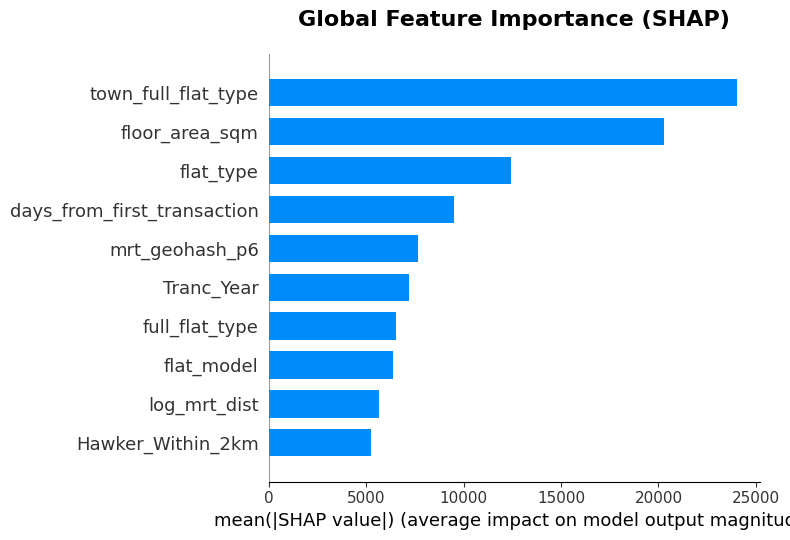

CatBoost Feature Importance Rankings (Top 10):
Rank  Feature                                             Importance
----------------------------------------------------------------------
1     town_full_flat_type                                       27.7
2     flat_type                                                  4.4
3     mrt_geohash_p6                                             4.0
4     floor_area_sqm                                             3.7
5     full_flat_type                                             3.5
6     flat_model                                                 3.4
7     days_from_first_transaction                                3.3
8     flat_type_ordinal                                          2.6
9     Tranc_Year                                                 2.3
10    Hawker_Within_2km                                          2.2


,Feature,SHAP_MeanAbs,CatBoost_Importance
0,town_full_flat_type,24005.319217,27.728008
1,floor_area_sqm,20300.815511,3.718203
2,flat_type,12449.324502,4.430265
3,days_from_first_transaction,9490.131165,3.274992
4,mrt_geohash_p6,7689.253845,3.995865
5,Tranc_Year,7178.691729,2.285263
6,full_flat_type,6539.389346,3.461493
7,flat_model,6399.487552,3.440347
8,log_mrt_dist,5648.327430,1.573162
9,Hawker_Within_2km,5246.952015,2.161508


In [22]:
# SHAP explanations on the held-out X_test using the tuned (not final) pipeline,
# so that interpretation references a model that has NOT seen the test rows.
import shap
import matplotlib.pyplot as plt

interp_pipeline = optuna_catboost_pipeline
final_model = interp_pipeline.named_steps['model']

# Recover the preprocessed feature names from the fitted ColumnTransformer.
# Cat columns come first, then passthrough numerics.
preprocessed_feature_names = list(
    interp_pipeline.named_steps['preprocessor'].get_feature_names_out()
)
# Strip the 'cat__' / 'remainder__' prefixes sklearn adds for cleaner labels.
preprocessed_feature_names = [
    name.split('__', 1)[-1] for name in preprocessed_feature_names
]

shap_sample_size = min(2000, len(X_test))
X_shap_raw = X_test.sample(n=shap_sample_size, random_state=42)
X_shap_transformed = interp_pipeline[:-1].transform(X_shap_raw)
X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=preprocessed_feature_names,
    index=X_shap_raw.index,
)

X_shap_pool = Pool(
    X_shap_df,
    cat_features=cat_feature_indices,
)

explainer = shap.TreeExplainer(final_model)

print('Calculating SHAP values...')
shap_values = explainer.shap_values(X_shap_pool)
print(f'SHAP values calculated for {shap_values.shape[0]} predictions')
print(f'Each prediction explained by {shap_values.shape[1]} transformed features')

catboost_importance = final_model.get_feature_importance()
shap_importance_values = np.mean(np.abs(shap_values), axis=0)

shap_importance = (
    pd.DataFrame({
        'Feature': preprocessed_feature_names,
        'SHAP_MeanAbs': shap_importance_values,
        'CatBoost_Importance': catboost_importance,
    })
    .sort_values('SHAP_MeanAbs', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_shap_df,
    feature_names=preprocessed_feature_names,
    plot_type='bar',
    max_display=10,
    show=False,
)
plt.title('Global Feature Importance (SHAP)', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print('CatBoost Feature Importance Rankings (Top 10):')
print('=' * 70)
print(f"{'Rank':<6}{'Feature':<50}{'Importance':>12}")
print('-' * 70)
catboost_ranking = shap_importance.sort_values('CatBoost_Importance', ascending=False).head(10).reset_index(drop=True)
for rank, row in catboost_ranking.iterrows():
    feature = row['Feature']
    if len(feature) > 47:
        feature = feature[:44] + '...'
    print(f"{rank + 1:<6}{feature:<50}{row['CatBoost_Importance']:>12.1f}")

shap_importance.head(30)


## 13. Feature Selection — Pruning Candidates (best params known)

Now that Optuna has converged on `optuna_best_params`/`optuna_best_iter`, feature selection becomes a refit-cost problem rather than a tuning problem. We can ablate features at known-good params and measure RMSE deltas directly.

Three complementary strategies, ordered cheap → rigorous:

| # | Strategy | Cost | Output |
|---|---|---|---|
| **1** | **Importance ranking** — CatBoost `LossFunctionChange` (target-aware) + cumulative SHAP threshold | 1 importance pass | sorted drop candidate list |
| **2** | **`CatBoostRegressor.select_features()`** — native recursive feature elimination with eval-set tracking | 1 call (~5 internal refits) | optimal subset + RMSE-vs-#features curve |
| **3** | **Direct ablation refit** — drop bottom-k transformed features, refit with best params, compare test RMSE | k refits | empirical RMSE delta per drop set |

Strategy 1 produces candidates. Strategy 2 picks an optimal subset. Strategy 3 confirms with a real refit. All three run on the held-out `X_test` for unbiased deltas.

**Note on transformed → raw column mapping.** Most transformed features map 1:1 to raw inputs (e.g., `log_mall_dist` derives from `Mall_Nearest_Distance`). Geohash buckets and engineered crosses are computed from raw lat/lon + categoricals — dropping them at the raw level requires removing the source columns or disabling the transformer. The cells below flag transformed-feature drops; map back manually before editing `drop_cols` in Section 4.


In [24]:
# ---------------------------------------------------------------------------
# STRATEGY 1 — Importance ranking.
#
# CatBoost's LossFunctionChange importance answers "how much does RMSE change
# if I remove this feature?" — directly target-aware, unlike the default
# PredictionValuesChange (which only measures prediction variance).
#
# Combine with cumulative SHAP threshold for cross-validation.
# ---------------------------------------------------------------------------
print('>>> Strategy 1: importance ranking')

# Build a Pool on the held-out test set for LossFunctionChange computation.
# Reuse the transformed test matrix that the SHAP cell already produced.
print('    transforming X_test for importance Pool ...')
X_test_transformed = interp_pipeline[:-1].transform(X_test)
test_pool = Pool(
    X_test_transformed,
    label=Y_test.values,
    cat_features=cat_feature_indices,
)

print('    computing LossFunctionChange importance (target-aware) ...')
loss_change = final_model.get_feature_importance(
    test_pool, type='LossFunctionChange',
)

importance_df = (
    pd.DataFrame({
        'Feature':              preprocessed_feature_names,
        'LossFunctionChange':   loss_change,
        'SHAP_MeanAbs':         shap_importance.set_index('Feature')
                                  .loc[preprocessed_feature_names, 'SHAP_MeanAbs'].values,
        'CatBoost_Importance':  shap_importance.set_index('Feature')
                                  .loc[preprocessed_feature_names, 'CatBoost_Importance'].values,
    })
    .sort_values('LossFunctionChange')
    .reset_index(drop=True)
)

# --- SHAP cumulative threshold ---
shap_sorted = importance_df.sort_values('SHAP_MeanAbs', ascending=False).reset_index(drop=True)
shap_sorted['cum_share'] = shap_sorted['SHAP_MeanAbs'].cumsum() / shap_sorted['SHAP_MeanAbs'].sum()
SHAP_KEEP_THRESHOLD = 0.99
drop_by_shap = set(shap_sorted.loc[shap_sorted['cum_share'] > SHAP_KEEP_THRESHOLD, 'Feature'])

# --- LossFunctionChange threshold ---
# Negative or near-zero = dropping the feature does NOT increase loss => candidate.
LFC_THRESHOLD = 0.0   # tightening to a small positive number drops more aggressively
drop_by_lfc = set(importance_df.loc[importance_df['LossFunctionChange'] <= LFC_THRESHOLD, 'Feature'])

# Intersection = high-confidence drop list.
drop_candidates = sorted(drop_by_shap & drop_by_lfc)

print()
print(f'    SHAP-based drop candidates (below {1 - SHAP_KEEP_THRESHOLD:.0%} cumulative): {len(drop_by_shap)}')
print(f'    LossFunctionChange drop candidates (<= {LFC_THRESHOLD}):                {len(drop_by_lfc)}')
print(f'    HIGH-CONFIDENCE intersection:                                      {len(drop_candidates)}')

print('\n>>> Top 15 drop candidates (lowest LossFunctionChange):')
print(importance_df.head(15).to_string(index=False))

print('\n>>> High-confidence drop list (low SHAP AND non-positive LFC):')
for f in drop_candidates:
    print(f'  - {f}')


>>> Strategy 1: importance ranking
    transforming X_test for importance Pool ...
    computing LossFunctionChange importance (target-aware) ...

    SHAP-based drop candidates (below 1% cumulative): 31
    LossFunctionChange drop candidates (<= 0.0):                18
    HIGH-CONFIDENCE intersection:                                      17

>>> Top 15 drop candidates (lowest LossFunctionChange):
              Feature  LossFunctionChange  SHAP_MeanAbs  CatBoost_Importance
     geo_cluster_prob           -4.959139    419.534053             0.108111
       geo_noise_flag           -3.634223     42.051741             0.005071
     log_pri_sch_dist           -2.706839    184.462969             0.057072
         log_bus_dist           -1.818807    131.689211             0.019453
            month_cos           -1.474015    128.901743             0.007036
         3room_rental           -1.011478     29.277797             0.001855
          Tranc_Month           -0.904916    302.434368    

>>> Strategy 2: CatBoost select_features() recursive elimination
    n_features=103  target_keep=51  steps=5
    running select_features (this trains multiple times) ...

    Selected (kept):    51 features
    Eliminated:         52 features

    Loss curve (eval RMSE vs # features removed):
 step    eval_rmse
    0 22571.247335
    1 22543.382504
    2 22519.381568
    3 22501.371058
    4 22488.745625
    5 22478.109515
    6 22468.180207
    7 22460.821331
    8 22454.057420
    9 22451.363344
   10 22451.292029
   11 22451.292029
   12 22451.292029
   13 22451.292029
   14 22451.292029
   15 22429.085594
   16 22429.085594
   17 22429.085594
   18 22429.085594
   19 22429.648110
   20 22432.482409
   21 22439.486810
   22 22447.777252
   23 22464.040373
   24 22495.589441
   25 22541.423207
   26 22541.773364
   27 22540.582842
   28 22539.343664
   29 22531.971554
   30 22523.466140
   31 22511.969491
   32 22494.994055
   33 22475.940481
   34 22455.142890
   35 22432.755434
   

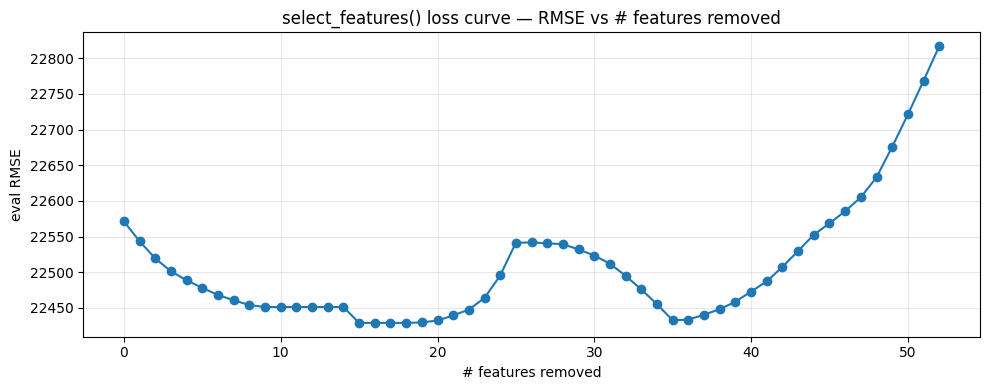


    >>> Optimal: remove 15 features (eval RMSE minimized).


In [25]:
# ---------------------------------------------------------------------------
# STRATEGY 2 — CatBoost native select_features().
#
# Recursive feature elimination using LossFunctionChange. Internally trains
# multiple times, dropping the lowest-impact feature each step. Returns:
#   - selected_features:    indices that survived
#   - eliminated_features:  indices dropped, in elimination order (worst first)
#   - loss_graph:           eval RMSE at each elimination step -> the "elbow"
#
# Uses optuna_best_params + optuna_best_iter, so this is feature selection at
# the tuned configuration. eval_set = transformed X_test.
# ---------------------------------------------------------------------------
from catboost import CatBoostRegressor

print('>>> Strategy 2: CatBoost select_features() recursive elimination')

X_train_transformed = interp_pipeline[:-1].transform(X_train)
train_pool = Pool(X_train_transformed, label=Y_train.values, cat_features=cat_feature_indices)
eval_pool  = Pool(X_test_transformed,  label=Y_test.values,  cat_features=cat_feature_indices)

n_features = X_train_transformed.shape[1]
NUM_TO_KEEP = max(10, n_features // 2)   # target subset size; tune to taste
STEPS       = 5                           # number of intermediate refits
print(f'    n_features={n_features}  target_keep={NUM_TO_KEEP}  steps={STEPS}')

selector = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    bootstrap_type='Bayesian',
    cat_features=cat_feature_indices,
    iterations=optuna_best_iter,
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1,
    **optuna_best_params,
)

print('    running select_features (this trains multiple times) ...')
result = selector.select_features(
    X=train_pool,
    eval_set=eval_pool,
    features_for_select=list(range(n_features)),
    num_features_to_select=NUM_TO_KEEP,
    steps=STEPS,
    algorithm='RecursiveByLossFunctionChange',
    shap_calc_type='Approximate',
    train_final_model=False,
    logging_level='Silent',
)

eliminated_idx = result['eliminated_features_names']  # already names if Pool had them
# Pool was built from numpy, so result returns indices — convert.
if eliminated_idx and isinstance(eliminated_idx[0], (int, np.integer)):
    eliminated_names = [preprocessed_feature_names[i] for i in eliminated_idx]
    selected_names   = [preprocessed_feature_names[i] for i in result['selected_features']]
else:
    eliminated_names = list(eliminated_idx)
    selected_names   = list(result['selected_features_names'])

loss_graph = result['loss_graph']
loss_curve_df = pd.DataFrame({
    'step':        loss_graph['removed_features_count'],
    'eval_rmse':   loss_graph['loss_values'],
})

print()
print(f'    Selected (kept):    {len(selected_names)} features')
print(f'    Eliminated:         {len(eliminated_names)} features')
print()
print('    Loss curve (eval RMSE vs # features removed):')
print(loss_curve_df.to_string(index=False))

print('\n    Eliminated features (in order of removal — worst first):')
for f in eliminated_names:
    print(f'      - {f}')

# Plot the loss curve.
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(loss_curve_df['step'], loss_curve_df['eval_rmse'], marker='o')
plt.xlabel('# features removed')
plt.ylabel('eval RMSE')
plt.title('select_features() loss curve — RMSE vs # features removed')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optimal cutoff = step where RMSE is minimum.
optimal_step = int(loss_curve_df.loc[loss_curve_df['eval_rmse'].idxmin(), 'step'])
print(f'\n    >>> Optimal: remove {optimal_step} features '
      f'(eval RMSE minimized).')


In [26]:
# ---------------------------------------------------------------------------
# STRATEGY 3 — Direct ablation refit at best params.
#
# Take the bottom-k transformed features by LossFunctionChange. Build a
# masked-feature CatBoost (drop those columns from the train/test matrices)
# and refit at exact optuna_best_params + optuna_best_iter. Compare test RMSE
# to the unmasked baseline.
#
# This is the empirical confirmation: "did the model actually get better?"
# ---------------------------------------------------------------------------
print('>>> Strategy 3: direct ablation refit at optuna_best_params')

# Sweep bottom-k for several k. Cheap because each refit reuses best params.
DROP_K_VALUES = [0, 5, 10, 20, 30]

# Cat columns occupy positions [0, len(catboost_categorical_cols)).
n_cat = len(catboost_categorical_cols)

baseline_rmse = None
ablation_results = []

for k in DROP_K_VALUES:
    if k == 0:
        keep_cols = list(range(n_features))
    else:
        # Bottom-k = features with lowest LossFunctionChange.
        bottom_features = importance_df.head(k)['Feature'].tolist()
        keep_cols = [
            i for i, name in enumerate(preprocessed_feature_names)
            if name not in set(bottom_features)
        ]

    X_tr_k = X_train_transformed[:, keep_cols]
    X_te_k = X_test_transformed[:,  keep_cols]
    cat_idx_k = [i for i, c in enumerate(keep_cols) if c < n_cat]

    print(f'\n    k={k:>3}: refitting with {len(keep_cols)} features (cat={len(cat_idx_k)}) ...')

    model_k = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_idx_k,
        iterations=optuna_best_iter,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **optuna_best_params,
    )
    model_k.fit(X_tr_k, Y_train.values)
    pred_k = model_k.predict(X_te_k)
    rmse_k = float(np.sqrt(mean_squared_error(Y_test, pred_k)))

    if k == 0:
        baseline_rmse = rmse_k
        delta = 0.0
    else:
        delta = rmse_k - baseline_rmse

    ablation_results.append({
        'drop_k':      k,
        'n_features':  len(keep_cols),
        'test_rmse':   rmse_k,
        'delta_vs_full': delta,
    })
    sign = '+' if delta >= 0 else ''
    print(f'        test_rmse={rmse_k:,.2f}  delta={sign}{delta:,.2f}')

ablation_df = pd.DataFrame(ablation_results)
print()
print('=== Ablation summary ===')
print(ablation_df.to_string(index=False))
print()
best_k_idx = ablation_df['test_rmse'].idxmin()
best_k = int(ablation_df.loc[best_k_idx, 'drop_k'])
print(f'>>> Best ablation: drop bottom-{best_k} features '
      f'(test RMSE = {ablation_df.loc[best_k_idx, "test_rmse"]:,.2f})')

if best_k > 0:
    print(f'\n>>> Drop list (map these back to raw cols before editing drop_cols):')
    for f in importance_df.head(best_k)['Feature'].tolist():
        print(f'  - {f}')


>>> Strategy 3: direct ablation refit at optuna_best_params

    k=  0: refitting with 103 features (cat=33) ...
        test_rmse=22,420.93  delta=+0.00

    k=  5: refitting with 98 features (cat=33) ...
        test_rmse=22,387.51  delta=-33.42

    k= 10: refitting with 93 features (cat=33) ...
        test_rmse=22,417.40  delta=-3.53

    k= 20: refitting with 83 features (cat=31) ...
        test_rmse=22,396.18  delta=-24.75

    k= 30: refitting with 73 features (cat=29) ...
        test_rmse=22,430.20  delta=+9.27

=== Ablation summary ===
 drop_k  n_features    test_rmse  delta_vs_full
      0         103 22420.929286       0.000000
      5          98 22387.505078     -33.424207
     10          93 22417.395689      -3.533596
     20          83 22396.181528     -24.747758
     30          73 22430.197516       9.268231

>>> Best ablation: drop bottom-5 features (test RMSE = 22,387.51)

>>> Drop list (map these back to raw cols before editing drop_cols):
  - geo_cluster_prob


In [ ]:
# ---------------------------------------------------------------------------
# Section 13b — Winner consolidation.
#
# Take the best drop_k from ablation_df (lowest test_rmse), refit one clean
# model at that subset, run it through regression_metrics(), and append to
# model_comparison so baseline / Optuna / Optuna+pruned sit on the same table.
# ---------------------------------------------------------------------------
print('>>> Section 13b: consolidate pruning winner')

best_row   = ablation_df.loc[ablation_df['test_rmse'].idxmin()]
best_drop  = int(best_row['drop_k'])
print(f'    best drop_k = {best_drop}  (test_rmse={best_row["test_rmse"]:,.2f}, '
      f'delta_vs_full={best_row["delta_vs_full"]:+,.2f})')

if best_drop == 0:
    # Pruning didn't help — winner IS the unpruned Optuna model.
    print('    >>> Pruning did NOT improve RMSE. Winner = Optuna (full feature set).')
    pruned_catboost_metrics = optuna_catboost_metrics.copy()
    pruned_catboost_metrics['model'] = 'Optuna CatBoost (no pruning helped)'
    pruned_features_dropped = []
else:
    # Refit at best_drop with the same feature mask as Strategy 3.
    pruned_features_dropped = importance_df.head(best_drop)['Feature'].tolist()
    keep_mask = [
        i for i, name in enumerate(preprocessed_feature_names)
        if name not in set(pruned_features_dropped)
    ]
    cat_idx_pruned = [i for i, c in enumerate(keep_mask) if c < len(catboost_categorical_cols)]

    print(f'    refitting on n={len(X_train):,}  features={len(keep_mask)}  '
          f'(dropped {len(pruned_features_dropped)}) ...')

    X_tr_p = X_train_transformed[:, keep_mask]
    X_te_p = X_test_transformed[:,  keep_mask]

    pruned_model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        bootstrap_type='Bayesian',
        cat_features=cat_idx_pruned,
        iterations=optuna_best_iter,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **optuna_best_params,
    )
    pruned_model.fit(X_tr_p, Y_train.values)
    print('    ... refit done.')

    Y_train_pred_pruned = pruned_model.predict(X_tr_p)
    Y_test_pred_pruned  = pruned_model.predict(X_te_p)

    pruned_catboost_metrics = regression_metrics(
        f'Optuna+Pruned (-{best_drop} feats)',
        Y_train,
        Y_train_pred_pruned,
        Y_test,
        Y_test_pred_pruned,
    )

# Final comparison: baseline vs Optuna vs Optuna+pruned, on the same X_test.
model_comparison_with_pruning = pd.concat(
    [baseline_metrics, optuna_catboost_metrics, pruned_catboost_metrics],
    ignore_index=True,
)

print()
print('=== Final model comparison (sorted by test RMSE) ===')
final_cmp = model_comparison_with_pruning.sort_values(['split', 'RMSE']).reset_index(drop=True)
print(final_cmp.to_string(index=False))

if best_drop > 0:
    print(f'\n>>> Dropped features ({best_drop}):')
    for f in pruned_features_dropped:
        print(f'  - {f}')

print()
print('>>> WINNER:')
test_rows = final_cmp[final_cmp['split'] == 'test']
winner = test_rows.loc[test_rows['RMSE'].idxmin()]
print(f"    {winner['model']}  -->  test RMSE = {winner['RMSE']:,.2f}")


## Appendix — Retired Scaler Code (reference only)

CatBoost is tree-based and invariant to monotonic transforms of numeric features, so StandardScaler/MinMaxScaler add cost without accuracy benefit. The scaler-based preprocessor is retained below, commented out, in case the same feature engineering is later reused with a linear/distance-based model that does benefit from scaling.


In [ ]:
# from sklearn.preprocessing import MinMaxScaler, StandardScaler
#
# std_scale_cols = [
#     'floor_area_sqm',
#     'Mall_Nearest_Distance',
#     'Hawker_Nearest_Distance',
#     'mrt_nearest_distance',
#     'bus_stop_nearest_distance',
#     'pri_sch_nearest_distance',
#     'sec_sch_nearest_dist',
#     'days_from_first_transaction',
#     'month_sin',
#     'month_cos',
#     'remaining_lease',
#     'property_age_at_sale',
#     'storey_mid_ratio',
#     'log_mrt_dist',
#     'log_mall_dist',
#     'log_hawker_dist',
#     'log_bus_dist',
#     'log_pri_sch_dist',
#     'log_sec_sch_dist',
#     'accessibility_score',
#     'geo_cluster_prob',
# ]
#
# minmax_scale_cols = [
#     '1room_sold',
#     'bus_interchange',
#     'mrt_interchange',
#     'pri_sch_affiliation',
#     'affiliation',
#     'lease_commence_date',
#     'Tranc_Year',
#     'Tranc_Month',
#     'mid_storey',
#     'lower',
#     'upper',
#     'mid',
#     'hdb_age',
#     'max_floor_lvl',
#     'year_completed',
#     'total_dwelling_units',
#     '2room_sold',
#     '3room_sold',
#     '4room_sold',
#     '5room_sold',
#     'exec_sold',
#     'multigen_sold',
#     'studio_apartment_sold',
#     '1room_rental',
#     '2room_rental',
#     '3room_rental',
#     'other_room_rental',
#     'Mall_Within_500m',
#     'Mall_Within_1km',
#     'Mall_Within_2km',
#     'Hawker_Within_500m',
#     'Hawker_Within_1km',
#     'Hawker_Within_2km',
#     'hawker_food_stalls',
#     'hawker_market_stalls',
#     'vacancy',
#     'cutoff_point',
#     'transaction_quarter',
#     'is_new_flat',
#     'is_old_flat',
#     'flat_type_ordinal',
#     'mrt_walkable',
#     'bus_walkable',
#     'mall_walkable',
#     'hawker_walkable',
#     'pri_school_walkable',
#     'sec_school_walkable',
#     'integrated_transport_access',
#     'geo_noise_flag',
# ]
#
# std_pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
#     ('scaler', StandardScaler()),
# ])
#
# minmax_pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
#     ('scaler', MinMaxScaler()),
# ])
#
# scaled_preprocessor = ColumnTransformer(transformers=[
#     ('std', std_pipeline, std_scale_cols),
#     ('minmax', minmax_pipeline, minmax_scale_cols),
#     ('cat', categorical_pipeline, catboost_categorical_cols),
# ])
#
# # If reused, recompute cat_feature_indices to match this column order:
# # scaled_preprocessed_feature_names = std_scale_cols + minmax_scale_cols + catboost_categorical_cols
# # scaled_cat_feature_indices = list(range(
# #     len(std_scale_cols) + len(minmax_scale_cols),
# #     len(scaled_preprocessed_feature_names),
# # ))
